# ramamurthy2019 — Ramamurthy et al. (2019) TDA of Decision Boundaries

Compare two **trained classifiers** by the topology of their decision boundaries — the paper's model-selection use of the labelled complex.


## What the paper does

TDA applied to **decision boundaries** for model selection.  Sample the input space, label each point by a classifier's **prediction**, and build a **labelled Vietoris–Rips** complex in which same-(predicted-)class pairs are masked to a sentinel distance — so the filtration only grows edges *between* the predicted classes.  The resulting persistent homology characterises the **decision-boundary** topology, not the data clusters.

**Methodology:** classifier predictions on a grid → same-class-masked VR complex → PH of the cross-class boundary.

**Expected result:** classifiers whose boundaries have different topology give different diagrams, so the diagrams *select the right model* without a held-out metric.


## Dataset & model in the paper

- **arXiv:** [https://arxiv.org/abs/1805.09949](https://arxiv.org/abs/1805.09949)
- **Venue:** ICML 2019
- **Datasets used:** Synthetic 2-D problems (XOR, concentric rings) + UCI tabular.
- **Models used:** Logistic regression, RBF-SVM, MLPs — model selection between them.  Here: logistic regression vs an MLP on concentric circles.
- **Headline result to aim for:** The labelled-complex PH diagram differentiates models that fit decision boundaries of different topology, guiding model selection.
- **Reference code:** no public repo found in web search — check paper supplementary materials.

To reproduce paper numbers, replace the synthetic-data cell below with the real model snapshot / activations / trajectory.  Everything else in the notebook stays the same.


**This notebook trains real classifiers.**  Concentric circles — a linear model *cannot* separate them (wrong, straight boundary); an MLP learns the correct *circular* boundary.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `paper_reproduce` importable
import numpy as np
import matplotlib.pyplot as plt
import torch
from tanc import TDAPipeline
from paper_reproduce._torch_setup import (
    load_mnist, load_fashion_mnist, load_cifar10, load_cifar100,
    SmallMLP, SmallCNN, CNN_FCN, CNN_FCN2, VGGLike, train_briefly, extract_snapshot, accuracy, pick_device,
)
np.random.seed(0); torch.manual_seed(0)
DEVICE = pick_device()                      # 'cuda' → 'mps' (Apple GPU) → 'cpu'


## 1. Concentric circles + two classifiers


In [2]:
from sklearn.linear_model import LogisticRegression
rng = np.random.default_rng(0)
n = 160; t = rng.uniform(0, 2*np.pi, n)
r = np.where(np.arange(n) < n//2, 0.5, 1.5) + 0.03*rng.standard_normal(n)
X = np.c_[r*np.cos(t), r*np.sin(t)].astype(np.float32)
y = (np.arange(n) >= n//2).astype(np.int64)

linear = LogisticRegression().fit(X, y)
mlp = SmallMLP(2, [32, 16], 2)
train_briefly(mlp, X, y, X, y, epochs=150, aspects=['activations'], device=DEVICE, verbose=False)
mlp.cpu().eval()
print('linear acc =', (linear.predict(X) == y).mean(),
      ' MLP acc =', accuracy(mlp, X, y, device='cpu'))


linear acc = 0.575  MLP acc = 1.0


## 2. Label a grid by each model's prediction → the decision boundary


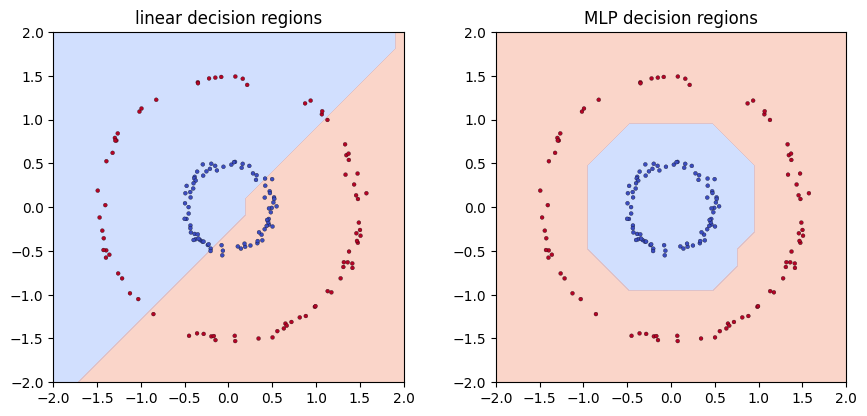

In [3]:
g = 22; xs = np.linspace(-2, 2, g); xx, yy = np.meshgrid(xs, xs)
grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
pred_lin = linear.predict(grid)
with torch.no_grad():
    pred_mlp = mlp(torch.from_numpy(grid)).argmax(1).numpy()

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
for ax, (name, p) in zip(axes, [('linear', pred_lin), ('MLP', pred_mlp)]):
    ax.contourf(xx, yy, p.reshape(g, g), levels=1, cmap='coolwarm', alpha=0.4)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=8, edgecolors='k', linewidths=0.2)
    ax.set_title(f'{name} decision regions'); ax.set_aspect('equal')
plt.tight_layout(); plt.show()


## 3. Boundary topology selects the model

The labelled-complex `H1` of each model's prediction grid: the wrong (straight) boundary and the correct (circular) boundary give **measurably different** diagrams.


  linear (straight) : H1 bars =     90  mean birth = 0.19
  MLP (circular)    : H1 bars =     21  mean birth = 0.19


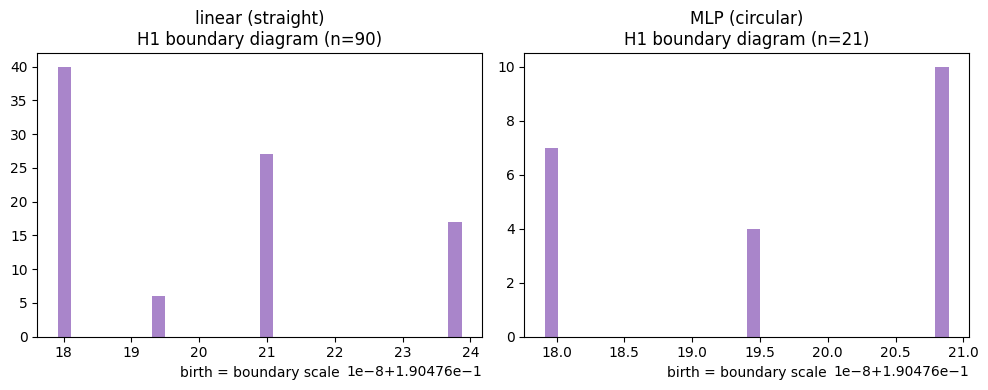

In [4]:
pipe = TDAPipeline.from_paper("ramamurthy2019")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, p) in zip(axes, [('linear (straight)', pred_lin), ('MLP (circular)', pred_mlp)]):
    d1 = pipe.fit((grid, p)).diagram(1)
    ax.hist(d1[:, 0], bins=30, color='tab:purple', alpha=0.8)
    ax.set_title(f'{name}\nH1 boundary diagram (n={len(d1)})')
    ax.set_xlabel('birth = boundary scale')
    print(f'  {name:18s}: H1 bars = {len(d1):6d}  mean birth = {d1[:, 0].mean():.2f}')
plt.tight_layout(); plt.show()


## Notes & gaps

* Implements the paper's **model-selection** use on **real trained classifiers**: the labelled-complex `H1` of the linear model's straight boundary differs clearly from the MLP's correct circular boundary (different bar counts and birth scales).
* The raw H1 *count* is large (every cross-class pair seeds structure in the sentinel-masked complex), so compare the **diagrams** (counts / births / Betti curves), not a single loop count — exactly the diagram-distance comparison the paper uses to rank models.


## Deviations from the paper

Everything this notebook does differently from the source, and why. An empty
table below means the construction follows the paper as written — that is a
claim, not an omission. Scale always differs; see the last row.

| aspect | the paper | this notebook | why it matters |
|---|---|---|---|
| scale | the paper's full experimental setup | a smaller model, fewer samples, fewer epochs | to keep the notebook runnable in minutes; expect weaker effects than published |
